# Titulo: Heterocedasticidad espacial.
## Diplomado: Geoestadística y análisis espacial
## SciData
## Instructor: Alexis Adonai Morales Alberto


In [36]:
# Modulos

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from google.colab import drive
from libpysal.weights import Queen
from libpysal.weights import Rook
from shapely.geometry import LineString
from libpysal.weights import KNN
from libpysal.weights import DistanceBand
from pysal.viz import splot
from pysal.explore import esda
from pysal.lib import weights
from splot.esda import plot_moran
from splot import esda as esdaplot

import libpysal
from esda import G_Local, LOSH



## Mapa temático para identificar el fenómeno

In [37]:
# Configuración de google drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [38]:
# Ruta completa del archivo

ruta_mapa = '/content/drive/MyDrive/SciData/GEOAES_25/Mapas/México_ent_22/00ent'
ruta_data = '/content/drive/MyDrive/SciData/GEOAES_25/Bases/Pobreza_rel_2024.csv'

In [39]:
# Cargar mapa

Mapa = gpd.read_file(ruta_mapa + '.shp')
Mapa.head(1)

Output hidden; open in https://colab.research.google.com to view.

In [40]:
# Cargar datos de pobreza 2024

Data = pd.read_csv(ruta_data)

Data.head(1)

,CVE_ENT,ENTIDAD,Pobreza
0,1,Aguascalientes,17.068482


In [41]:
# Verificar columnas

Mapa['CVE_ENT'] = pd.to_numeric(Mapa['CVE_ENT'], errors = 'coerce')

Mapa[['CVE_ENT', 'NOMGEO']].dtypes

,0
CVE_ENT,int64
NOMGEO,object


In [42]:
Mapa.head(1)

Output hidden; open in https://colab.research.google.com to view.

In [43]:
Data[['CVE_ENT', 'ENTIDAD']].dtypes

,0
CVE_ENT,int64
ENTIDAD,object


In [44]:
# Combinar datos con el mapa

Mapa = Mapa.merge(
    Data,
    left_on= ["CVE_ENT","NOMGEO"],
    right_on=["CVE_ENT","ENTIDAD"],
    how = 'left'
)

In [45]:
Mapa.head(1)

Output hidden; open in https://colab.research.google.com to view.

In [46]:
Mapa.dtypes

,0
CVEGEO,object
CVE_ENT,int64
NOMGEO,object
geometry,geometry
ENTIDAD,object
Pobreza,float64


In [47]:
Mapa = Mapa.rename(columns={'Pobreza ': 'Pobreza'}) # Aportación de Jorge Calvillo

<Figure size 7500x6000 with 0 Axes>

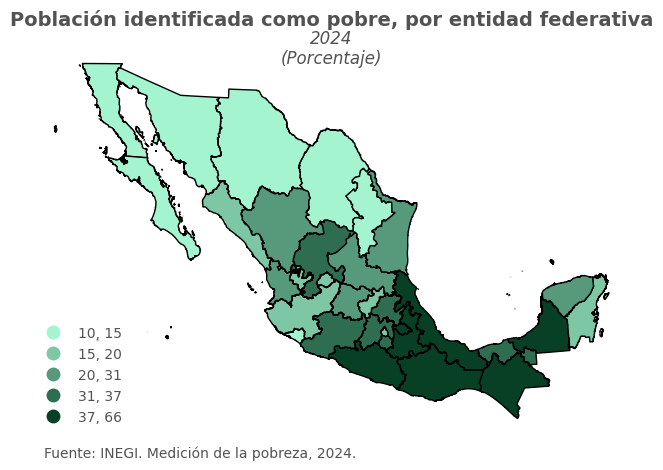

In [48]:
# Definición de paleta

from matplotlib.colors import ListedColormap

Colores = ["#A4F4CF", "#7DC7A5", "#569A7B", "#2F6D51", "#084026"]

cmap_manual = ListedColormap(Colores)

# Mapa temático con variable continua

plt.figure(figsize=(15,12), dpi = 500)
Mapa.plot(
    column = 'Pobreza',
    scheme = 'Quantiles',
    k = 5,
    legend = True,
    cmap = cmap_manual,
    legend_kwds = {'loc': 'lower left',
                   'fmt': "{:.0f}"},
    edgecolor = "black"
)
plt.axis('off') # Quita los ejes
plt.figtext(0.5, 0.95, "Población identificada como pobre, por entidad federativa",
            fontweight = 'bold',
            color = "#525252",
            ha = 'center',
            fontsize = 14) # Titulo
plt.figtext(0.5, 0.87, "2024\n(Porcentaje)",
            style = "italic",
            color = "#525252",
            ha = 'center',
            fontsize = 12) # Subtitulo
plt.figtext(0.05, 0.05, "Fuente: INEGI. Medición de la pobreza, 2024.",
            color = "#525252",
            fontsize = 10) # Pie de gráfico
ax = plt.gca()
leg = ax.get_legend()
for text in leg.get_texts():
  text.set_color('#525252')
if leg is not None:
  leg.get_frame().set_linewidth(0)
  leg.get_frame().set_edgecolor("none")
plt.grid(False)
plt.tight_layout(rect = [0,0.05,1,0.95])
ruta_guardado = '/content/drive/MyDrive/SciData/GEOAES_25/Salidas/Mapa_pobreza.png'
plt.savefig(ruta_guardado, dpi = 500, bbox_inches = 'tight', facecolor = 'white')

## Matrices de pesos espaciales


1. Contiguedad de Reina



In [49]:
# Cálculo de matriz

W_queen = Queen.from_dataframe(Mapa, ids = "CVE_ENT")

# Normalizar filas

W_queen.transform = 'r'

# Heterocedasticidad espacial

1. Getis-Ord Local G (Gi*)

¿Qué mide?

- Detecta agrupamientos locales de valores altos con bajos.
- No mide varianza, sino intensidad local.

In [50]:
np.random.seed(123)

# Cálculo de Getis-Ord

gi_local = G_Local(Mapa['Pobreza'], W_queen)

In [51]:
# Resultados princiales

gi_local.Gs

array([0.03129283, 0.01368895, 0.01113379, 0.03069202, 0.02544115,
       0.0300115 , 0.05252484, 0.02023858, 0.03793969, 0.0240347 ,
       0.03125538, 0.04671428, 0.03998389, 0.02889769, 0.04091393,
       0.03191877, 0.04423512, 0.02861003, 0.0280307 , 0.06269961,
       0.0496928 , 0.03570741, 0.03605502, 0.03121063, 0.02290631,
       0.01585412, 0.05692885, 0.03250474, 0.04281433, 0.04721566,
       0.03131337, 0.02418132])

In [52]:
gi_local.p_sim

array([0.461, 0.008, 0.032, 0.483, 0.213, 0.463, 0.018, 0.041, 0.303,
       0.109, 0.494, 0.025, 0.12 , 0.296, 0.048, 0.491, 0.083, 0.341,
       0.302, 0.001, 0.003, 0.293, 0.356, 0.464, 0.091, 0.01 , 0.013,
       0.462, 0.145, 0.005, 0.496, 0.049], dtype=float32)

In [53]:
# Contrucción de dataframe para los resultados

Gi = pd.DataFrame(
    {
        "CVE_ENT": Mapa['CVE_ENT'],
        "Entidades": Mapa['NOMGEO'],
        "Getis_Ord": gi_local.Zs,
        "Prob": gi_local.p_sim
    }
)

Gi['Signo'] = np.where(
    Gi['Getis_Ord'] > 0, "Rodeado de altos",
    np.where(Gi['Getis_Ord'] < 0, "Rodeado de bajos", "Igual 0")
)

alpha = 0.05
Gi['Significativo'] = np.where(
    Gi['Prob'] <= alpha, "Significativo", "No significativo"
)

Gi['Cluster'] = np.select(
    [
        (Gi['Getis_Ord'] > 0) & (Gi['Prob'] <= alpha),
        (Gi['Getis_Ord'] < 0) & (Gi['Prob'] <= alpha)
    ],
    [
        "Hot spot",
        "Cold spot"
    ],
    default = "No significativo"
)

Gi

,CVE_ENT,Entidades,Getis_Ord,Prob,Signo,Significativo,Cluster
0,1,Aguascalientes,-0.059760,0.461,Rodeado de bajos,No significativo,No significativo
1,2,Baja California,-1.179622,0.008,Rodeado de bajos,Significativo,Cold spot
2,3,Baja California Sur,-1.340270,0.032,Rodeado de bajos,Significativo,Cold spot
3,4,Campeche,-0.094447,0.483,Rodeado de bajos,No significativo,No significativo
4,5,Coahuila de Zaragoza,-0.428732,0.213,Rodeado de bajos,No significativo,No significativo
5,6,Colima,-0.140002,0.463,Rodeado de bajos,No significativo,No significativo
6,7,Chiapas,1.339737,0.018,Rodeado de altos,Significativo,Hot spot
7,8,Chihuahua,-0.748697,0.041,Rodeado de bajos,Significativo,Cold spot
8,9,Ciudad de México,0.349230,0.303,Rodeado de altos,No significativo,No significativo
9,10,Durango,-0.497965,0.109,Rodeado de bajos,No significativo,No significativo


In [55]:
# Combinar datos con el mapa

Mapa = Mapa.merge(
    Gi[['CVE_ENT', 'Significativo', 'Cluster']],
    left_on= ["CVE_ENT"],
    right_on=["CVE_ENT"],
    how = 'inner'
)

Mapa

Output hidden; open in https://colab.research.google.com to view.

2. Estadístico local LOSH

¿Qué mide?

- Evalúa si la dispersión local difiere del promedio global.
- Diseñado especificamente para heterocedasticidad espacial.

In [62]:
# Cálculo de local LOSH

losh = LOSH(connectivity=W_queen, inference='chi-square').fit(Mapa['Pobreza'])

In [67]:
H = pd.DataFrame({
    "CVE_ENT": Mapa['CVE_ENT'],
    "Entidades": Mapa['NOMGEO'],
    "LOSH": losh.Hi,
    "Prob": losh.pval
})

H['Comparacion'] = np.where(
    H['LOSH'] > 1, "Mayor varianza",
    np.where(H['LOSH'] < 1, "Menor varianza", "Igualdad")
)

alpha = 0.05
H['Significativo_LOSH'] = np.where(
    H['Prob'] <= alpha,
    "Significativo",
    "No significativo"
)

H['Patron_LOSH'] = np.select(
    [
        (H['LOSH'] > 1) & (H['Prob'] <= alpha),
        (H['LOSH'] < 1) & (H['Prob'] <= alpha)
    ],
    [
        "Alta heterocedasticidad local",
        "Baja heterocedasticidad local"
    ],
    default = "No significativo"
)

H

,CVE_ENT,Entidades,LOSH,Prob,Comparacion,Significativo_LOSH,Patron_LOSH
0,1,Aguascalientes,1.610870,0.194161,Mayor varianza,No significativo,No significativo
1,2,Baja California,0.000569,0.999850,Menor varianza,No significativo,No significativo
2,3,Baja California Sur,0.057310,0.845269,Menor varianza,No significativo,No significativo
3,4,Campeche,1.477987,0.209548,Mayor varianza,No significativo,No significativo
4,5,Coahuila de Zaragoza,1.401669,0.218775,Mayor varianza,No significativo,No significativo
5,6,Colima,0.507994,0.634498,Menor varianza,No significativo,No significativo
6,7,Chiapas,0.829469,0.498502,Menor varianza,No significativo,No significativo
7,8,Chihuahua,0.448869,0.818583,Menor varianza,No significativo,No significativo
8,9,Ciudad de México,0.141122,0.900830,Menor varianza,No significativo,No significativo
9,10,Durango,0.814637,0.569082,Menor varianza,No significativo,No significativo


In [69]:
# Unión de datos con el mapa

Mapa = Mapa.merge(
    H[['CVE_ENT', 'Significativo_LOSH', 'Patron_LOSH']],
    left_on= ["CVE_ENT"],
    right_on=["CVE_ENT"],
    how = 'inner'
)

Mapa

Output hidden; open in https://colab.research.google.com to view.

3. Visualización del mapa integrando local Gi y LOSH

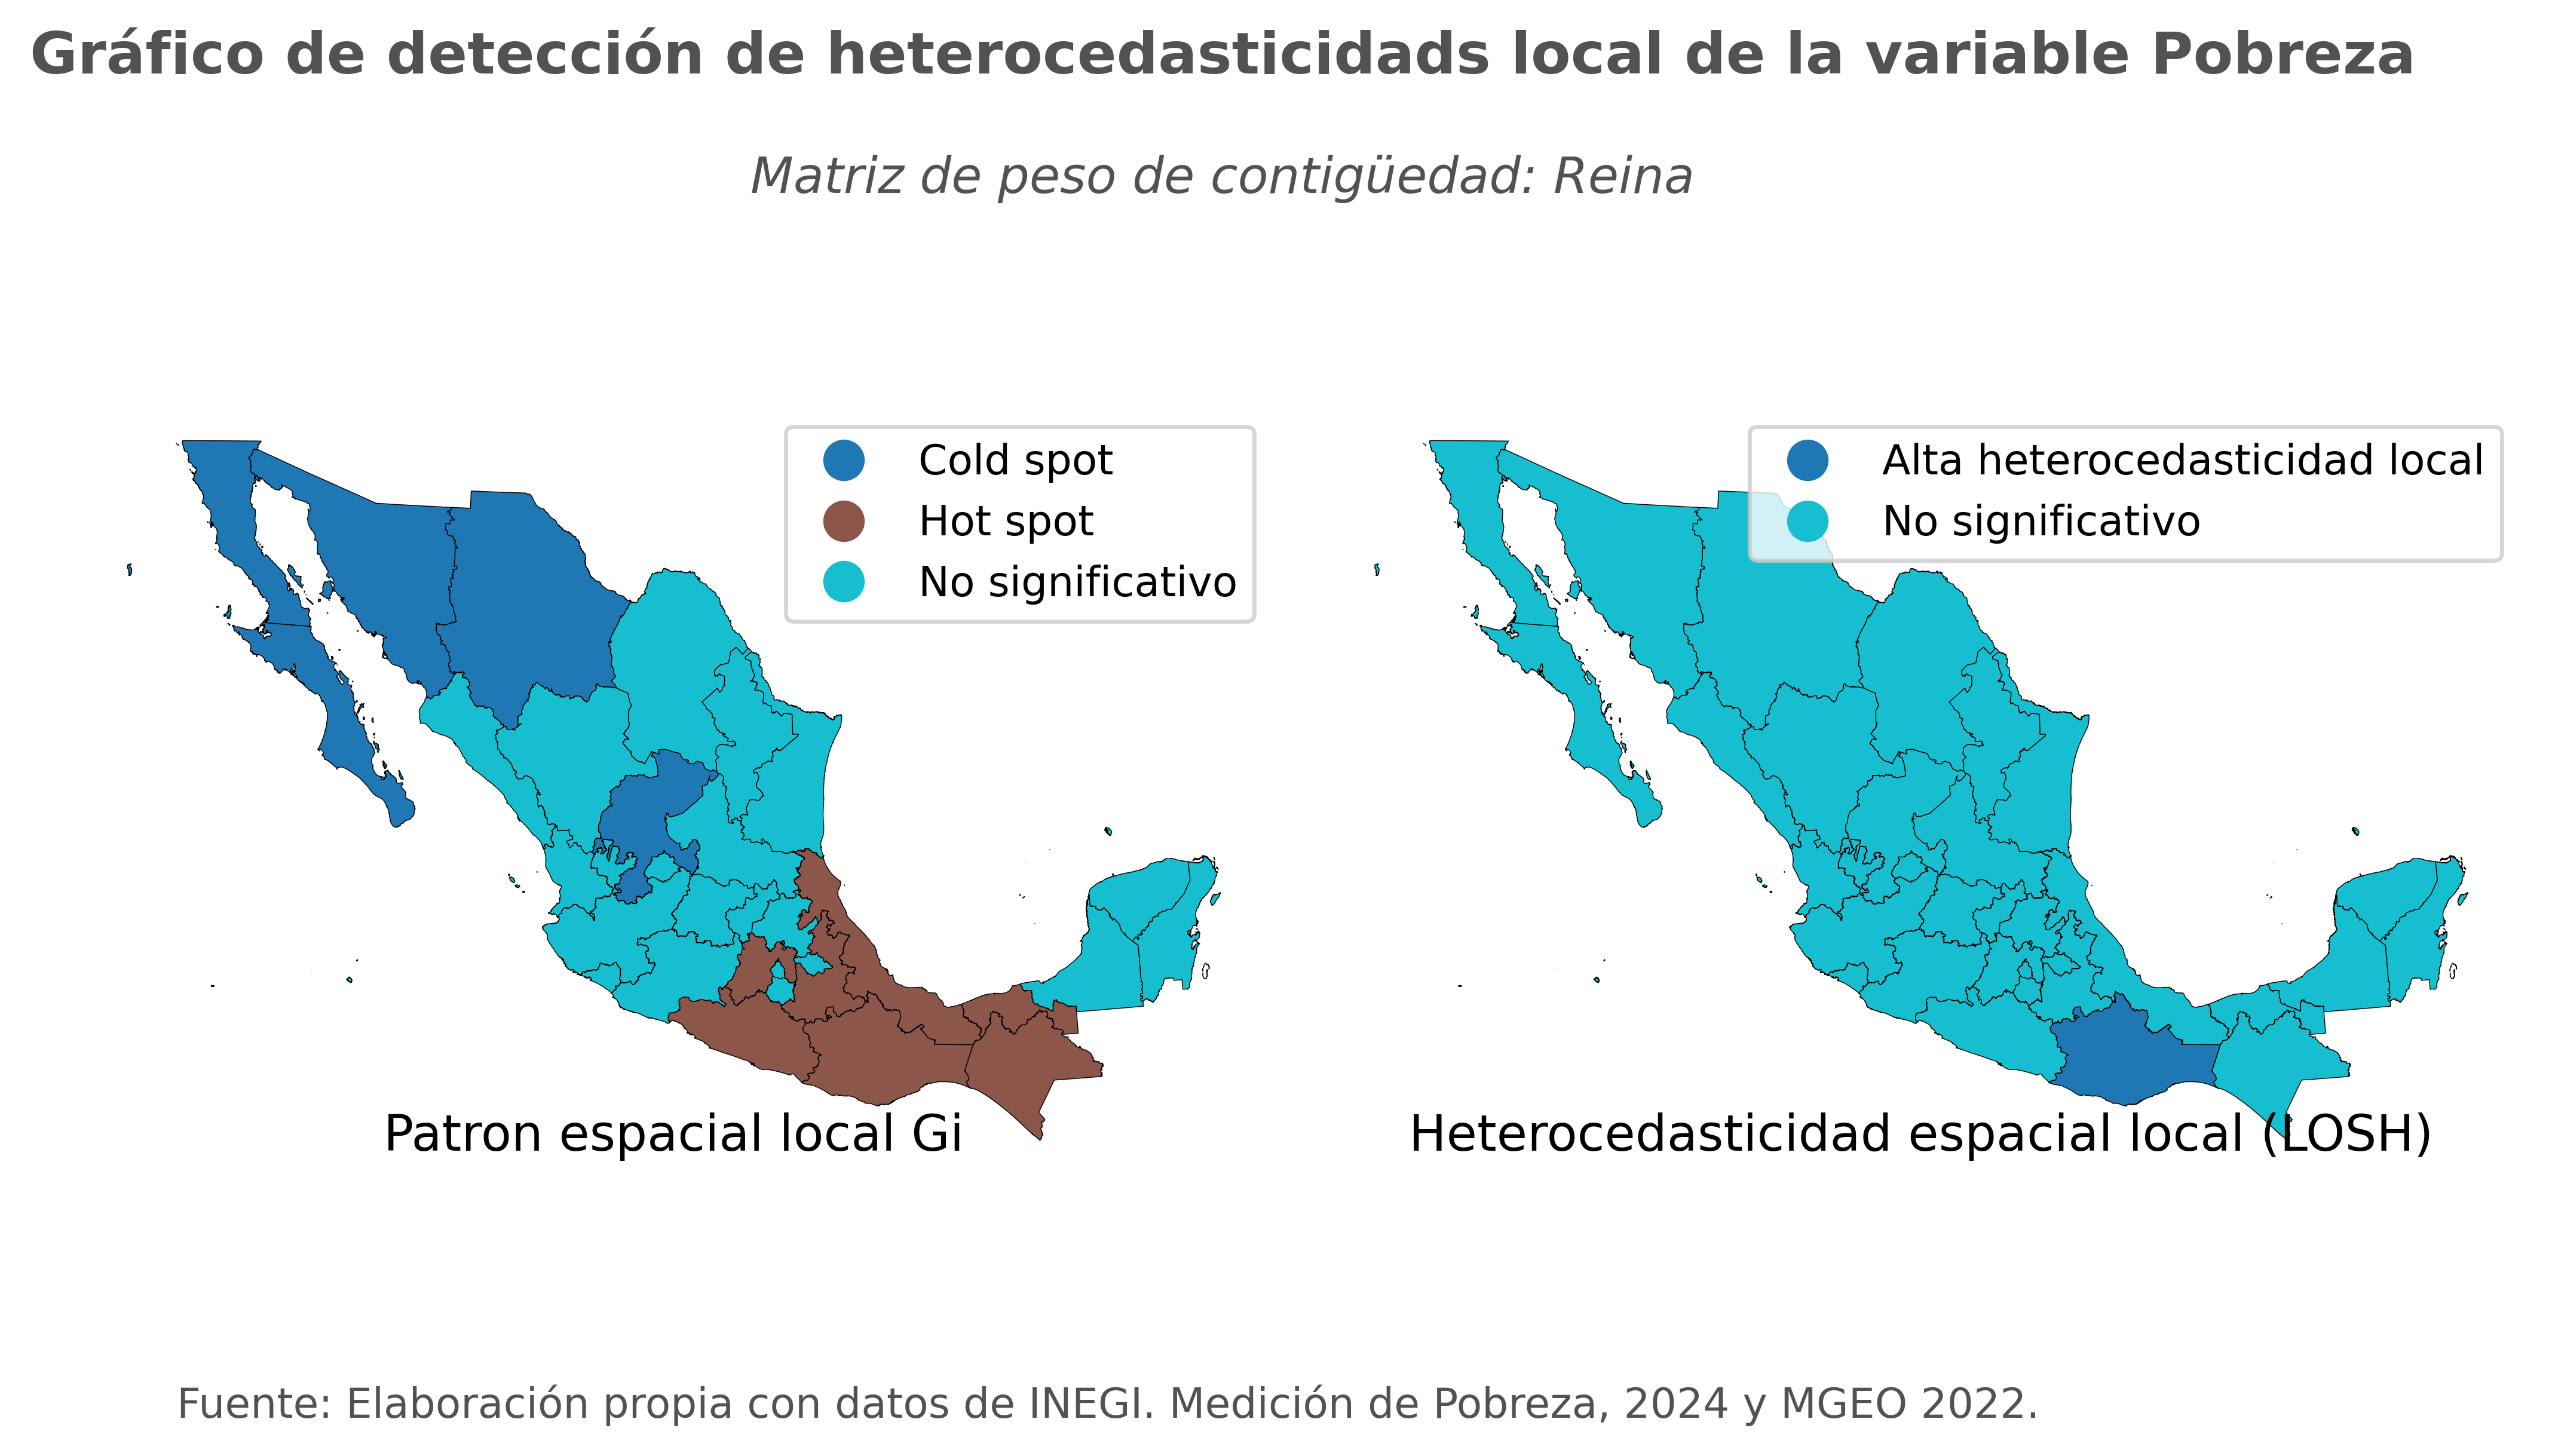

In [73]:
# Mapa que permite identificación de I. Moran local con significancia estadística

f, axs = plt.subplots(nrows = 1, ncols =2, figsize = (10,5), dpi = 500)
axs = axs.flatten()

# Local Gi

Mapa.plot(
    column = 'Cluster',
    categorical = True,
    legend = True,
    ax = axs[0],
    edgecolor = 'black',
    linewidth = 0.2
)

Mapa.plot(
    column = 'Patron_LOSH',
    categorical = True,
    legend = True,
    ax = axs[1],
    edgecolor = 'black',
    linewidth = 0.2
)

for i, ax in enumerate(axs.flatten()):
  ax.set_axis_off()
  ax.set_title(
      [
          "Patron espacial local Gi",
          "Heterocedasticidad espacial local (LOSH)"
      ][i],
      y = 0
  )
plt.figtext(0.4, 0.95, "Gráfico de detección de heterocedasticidads local de la variable Pobreza",
            fontweight = 'bold',
            color = "#525252",
            ha = 'center',
            fontsize = 14) # Titulo
plt.figtext(0.4, 0.87, "Matriz de peso de contigüedad: Reina",
            style = "italic",
            color = "#525252",
            ha = 'center',
            fontsize = 12) # Subtitulo
plt.figtext(0.05, 0.05, "Fuente: Elaboración propia con datos de INEGI. Medición de Pobreza, 2024 y MGEO 2022.",
            color = "#525252",
            fontsize = 10) # Pie de gráfico
ax = plt.gca()
plt.grid(False)
plt.tight_layout(rect = [0,0.05,0.85,0.89])
ruta_guardado = '/content/drive/MyDrive/SciData/GEOAES_25/Salidas/Heterocedasticidad_Local_pobreza.png'
plt.savefig(ruta_guardado, dpi = 500, bbox_inches = 'tight', facecolor = 'white')